# Autonomous Driving Inference Notebook

YOLO detection + traffic light color analysis + simple decision engine.

In [70]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


In [71]:
PROJECT_ROOT = Path(r"C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project")
MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "bdd_yolo_v14" / "weights" / "best.pt"
IMAGE_PATH = PROJECT_ROOT / "outputs" / "prepared_data" / "bdd_yolo" / "images" / "val" / "b4607812-48ed5dcb.jpg"

print("MODEL_PATH:", MODEL_PATH)
print("IMAGE_PATH:", IMAGE_PATH)

MODEL_PATH: C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\outputs\models\bdd_yolo_v14\weights\best.pt
IMAGE_PATH: C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\outputs\prepared_data\bdd_yolo\images\val\b4607812-48ed5dcb.jpg


In [72]:
def clamp_box(box, frame_shape):
    h, w = frame_shape[:2]
    x1, y1, x2, y2 = box
    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(0, min(int(x2), w - 1))
    y2 = max(0, min(int(y2), h - 1))
    if x2 <= x1:
        x2 = min(w - 1, x1 + 1)
    if y2 <= y1:
        y2 = min(h - 1, y1 + 1)
    return x1, y1, x2, y2

def crop_from_box(frame, box):
    x1, y1, x2, y2 = clamp_box(box, frame.shape)
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return crop

def draw_box(frame, box, label, color=(0, 255, 0), thickness=2):
    x1, y1, x2, y2 = clamp_box(box, frame.shape)
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
    ((text_w, text_h), _) = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    y_text = max(20, y1 - 8)
    cv2.rectangle(frame, (x1, max(0, y_text - text_h - 8)), (x1 + text_w + 8, y_text + 4), color, -1)
    cv2.putText(frame, label, (x1 + 4, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2, cv2.LINE_AA)
    return frame

def show_bgr(img, title="image", figsize=(12, 8)):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


In [73]:
def count_mask_pixels(hsv, lower, upper):
    mask = cv2.inRange(hsv, lower, upper)
    return int(np.count_nonzero(mask)), mask

def detect_traffic_light_color(crop):
    if crop is None or crop.size == 0:
        return {"state": "unknown", "scores": {"red": 0, "yellow": 0, "green": 0}}

    h, w = crop.shape[:2]
    if h < 8 or w < 8:
        return {"state": "unknown", "scores": {"red": 0, "yellow": 0, "green": 0}}

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    top = hsv[0:h // 3, :]
    mid = hsv[h // 3: 2 * h // 3, :]
    bot = hsv[2 * h // 3:, :]

    red_1_low = np.array([0, 90, 90], dtype=np.uint8)
    red_1_up  = np.array([10, 255, 255], dtype=np.uint8)
    red_2_low = np.array([160, 90, 90], dtype=np.uint8)
    red_2_up  = np.array([180, 255, 255], dtype=np.uint8)
    yellow_low = np.array([15, 90, 90], dtype=np.uint8)
    yellow_up  = np.array([40, 255, 255], dtype=np.uint8)
    green_low = np.array([40, 70, 70], dtype=np.uint8)
    green_up  = np.array([95, 255, 255], dtype=np.uint8)

    red_count_1, _ = count_mask_pixels(top, red_1_low, red_1_up)
    red_count_2, _ = count_mask_pixels(top, red_2_low, red_2_up)
    red_score = red_count_1 + red_count_2
    yellow_score, _ = count_mask_pixels(mid, yellow_low, yellow_up)
    green_score, _ = count_mask_pixels(bot, green_low, green_up)

    scores = {"red": red_score, "yellow": yellow_score, "green": green_score}
    best_state = max(scores, key=scores.get)
    best_score = scores[best_state]
    min_pixels = max(10, int((h * w) * 0.01))
    if best_score < min_pixels:
        best_state = "unknown"
    return {"state": best_state, "scores": scores}


In [74]:
def estimate_distance_level(box, frame_shape):
    h, w = frame_shape[:2]
    x1, y1, x2, y2 = box
    box_h = max(1, y2 - y1)
    ratio = box_h / float(h)
    if ratio > 0.45:
        return "very_near"
    if ratio > 0.28:
        return "near"
    if ratio > 0.14:
        return "medium"
    return "far"

def decision_engine(detections, frame_shape):
    summary = {
        "traffic_light_state": "unknown",
        "action": "GO",
        "risk": "LOW",
        "notes": []
    }

    persons = [d for d in detections if d["class_name"] == "person"]
    cars = [d for d in detections if d["class_name"] == "car"]
    traffic_lights = [d for d in detections if d["class_name"] == "traffic light"]

    if traffic_lights:
        tl = max(traffic_lights, key=lambda d: d["conf"])
        tl_state = tl.get("traffic_light_state", "unknown")
        summary["traffic_light_state"] = tl_state
        if tl_state == "red":
            summary["action"] = "STOP"
            summary["risk"] = "HIGH"
            summary["notes"].append("red_light")
        elif tl_state == "yellow":
            summary["action"] = "SLOW"
            summary["risk"] = "MEDIUM"
            summary["notes"].append("yellow_light")

    for person in persons:
        dist = estimate_distance_level(person["box"], frame_shape)
        if dist in {"very_near", "near"}:
            summary["action"] = "STOP"
            summary["risk"] = "CRITICAL"
            summary["notes"].append("near_person")
            break

    if summary["action"] != "STOP":
        for car in cars:
            dist = estimate_distance_level(car["box"], frame_shape)
            if dist == "very_near":
                summary["action"] = "STOP"
                summary["risk"] = "HIGH"
                summary["notes"].append("very_near_car")
                break
            elif dist == "near":
                summary["action"] = "SLOW"
                if summary["risk"] == "LOW":
                    summary["risk"] = "MEDIUM"
                summary["notes"].append("near_car")
                break

    return summary


In [75]:
model = YOLO(str(MODEL_PATH))
print("Model yüklendi.")


Model yüklendi.


In [76]:
frame = cv2.imread(str(IMAGE_PATH))
if frame is None:
    raise ValueError(f"Görsel okunamadı: {IMAGE_PATH}")

results = model.predict(source=frame, conf=0.30, iou=0.45, verbose=False)
result = results[0]

detections = []
if result.boxes is not None:
    for box in result.boxes:
        xyxy = box.xyxy[0].tolist()
        conf = float(box.conf[0].item())
        cls_id = int(box.cls[0].item())
        cls_name = result.names[cls_id]
        detections.append({
            "box": tuple(map(int, xyxy)),
            "conf": conf,
            "class_id": cls_id,
            "class_name": cls_name
        })

print("Detection sayısı:", len(detections))
detections[:10]


Detection sayısı: 20


[{'box': (886, 297, 1083, 370),
  'conf': 0.8459363579750061,
  'class_id': 0,
  'class_name': 'car'},
 {'box': (1042, 251, 1177, 510),
  'conf': 0.7960327863693237,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (237, 239, 358, 500),
  'conf': 0.7845725417137146,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (537, 294, 608, 362),
  'conf': 0.702610194683075,
  'class_id': 0,
  'class_name': 'car'},
 {'box': (115, 263, 211, 526),
  'conf': 0.6802118420600891,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (813, 296, 849, 370),
  'conf': 0.6731919050216675,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (1193, 299, 1279, 366),
  'conf': 0.6088119149208069,
  'class_id': 0,
  'class_name': 'car'},
 {'box': (187, 260, 263, 493),
  'conf': 0.5910002589225769,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (1034, 249, 1051, 268),
  'conf': 0.5658906102180481,
  'class_id': 2,
  'class_name': 'traffic light'},
 {'box': (667, 312, 695, 335),
  'conf': 0.56398171

In [77]:
traffic_light_crops = []

for det in detections:
    if det["class_name"] == "traffic light":
        crop = crop_from_box(frame, det["box"])
        tl_info = detect_traffic_light_color(crop)
        det["traffic_light_state"] = tl_info["state"]
        det["traffic_light_scores"] = tl_info["scores"]
        traffic_light_crops.append((crop, tl_info, det))

print("Traffic light sayısı:", len(traffic_light_crops))
for _, tl_info, det in traffic_light_crops:
    print(det["box"], tl_info["state"], tl_info["scores"])


Traffic light sayısı: 2
(1034, 249, 1051, 268) red {'red': 66, 'yellow': 21, 'green': 0}
(846, 85, 874, 137) red {'red': 293, 'yellow': 0, 'green': 0}


Traffic Light 1 | state=red | scores={'red': 66, 'yellow': 21, 'green': 0}


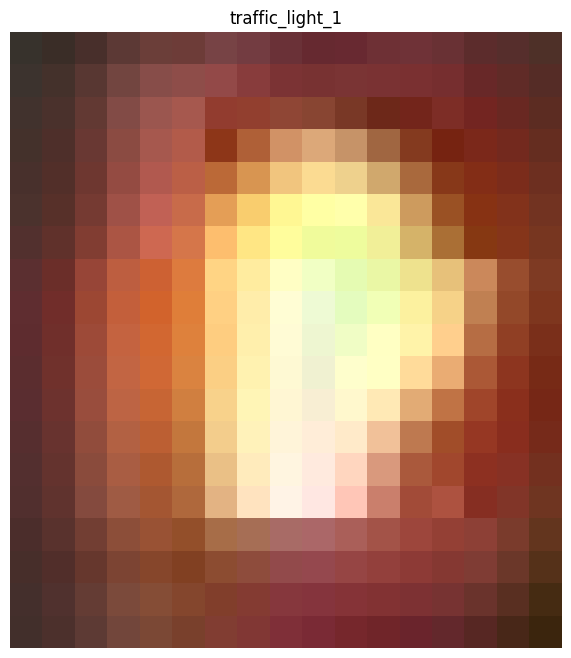

Traffic Light 2 | state=red | scores={'red': 293, 'yellow': 0, 'green': 0}


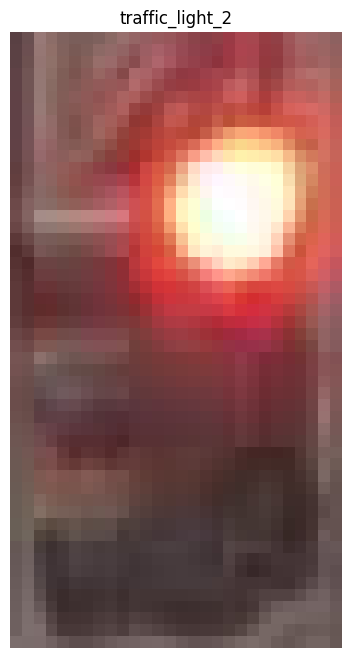

In [78]:
for i, (crop, tl_info, det) in enumerate(traffic_light_crops):
    if crop is not None:
        print(f"Traffic Light {i+1} | state={tl_info['state']} | scores={tl_info['scores']}")
        show_bgr(crop, title=f"traffic_light_{i+1}")


In [79]:
summary = decision_engine(detections, frame.shape)
summary


{'traffic_light_state': 'red',
 'action': 'STOP',
 'risk': 'CRITICAL',
 'notes': ['red_light', 'near_person']}

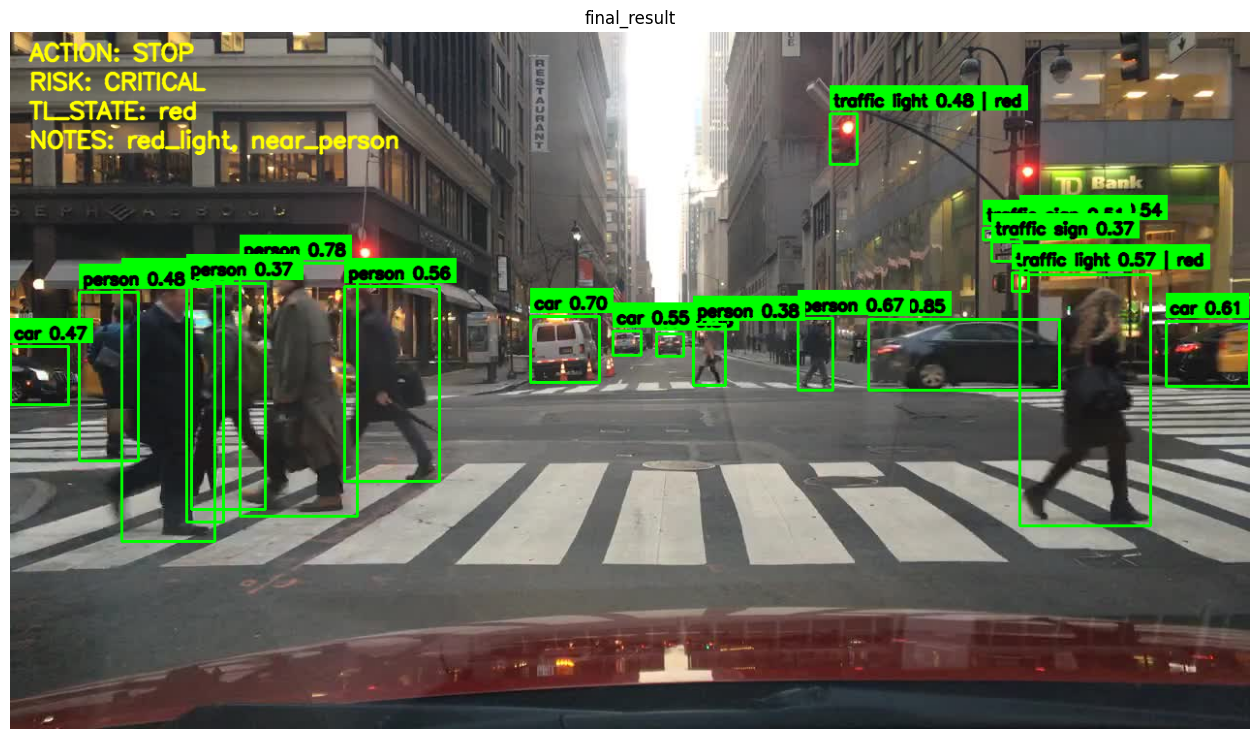

In [80]:
vis = frame.copy()

for det in detections:
    label = f"{det['class_name']} {det['conf']:.2f}"
    if det["class_name"] == "traffic light":
        label += f" | {det.get('traffic_light_state', 'unknown')}"
    draw_box(vis, det["box"], label)

overlay_lines = [
    f"ACTION: {summary['action']}",
    f"RISK: {summary['risk']}",
    f"TL_STATE: {summary['traffic_light_state']}",
    f"NOTES: {', '.join(summary['notes']) if summary['notes'] else '-'}",
]

y = 30
for line in overlay_lines:
    cv2.putText(vis, line, (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2, cv2.LINE_AA)
    y += 30

show_bgr(vis, title="final_result", figsize=(16, 10))


In [81]:
OUT_PATH = PROJECT_ROOT / "outputs" / "predictions" / "notebook_result.jpg"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(OUT_PATH), vis)
print("Kaydedildi:", OUT_PATH)

Kaydedildi: C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\outputs\predictions\notebook_result.jpg
